# Assignment 02 — Application 2: House-Price Prediction

**Student:** &lt;name&gt; &lt;id&gt;  |  **Class:** &lt;class&gt;  |  **Date:** 2026-09-03  
**Lecturer:** Dinh Que Tran, Ph.D., Assoc. Prof.  |  **Semester:** I.2026

The 23 sections below take the raw Vietnamese real-estate listings CSV through

```mermaid
flowchart LR
    Data --> Understand --> Clean --> Represent --> Learn --> Evaluate --> Persist --> Deploy
```

Every table or figure is followed by a short markdown interpretation. `RANDOM_SEED = 42`
everywhere. The persisted pipeline written in section 22 is what `../api/` serves.

## 0. Header & setup

Fix and print the environment (seed + library versions) so the experiment is reproducible.

In [1]:
import sys, platform, random, time, warnings
import numpy as np, pandas as pd
import sklearn, matplotlib, matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print('Python      :', sys.version.split()[0], 'on', platform.system(), platform.release())
print('numpy       :', np.__version__)
print('pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)
try:
    import xgboost; print('xgboost     :', xgboost.__version__)
except ImportError:
    print('xgboost     : NOT INSTALLED  (pip install xgboost)')
print('RANDOM_SEED  =', RANDOM_SEED)

Python      : 3.14.6 on Windows 11
numpy       : 2.4.6
pandas      : 3.0.3
scikit-learn: 1.9.0
matplotlib  : 3.11.0
xgboost     : 3.3.0
RANDOM_SEED  = 42


## 1. Problem definition

**Task:** regression — predict a residential listing's price from its attributes.
Scored with MAE / RMSE / R² (no accuracy / confusion matrix).

- `X` = area, frontage/length, room counts, floors, alley width, property type,
  position, direction, road type, province, and a `district` parsed from `Location`.
- `y` = `Price` in **million VND** ("2.7 tỷ" ↔ `Price` = 2700).

$$ X \in \mathbb{R}^{N \times d}, \qquad y \in \mathbb{R}^{N} $$

## 2. Dataset source

| Field | Value |
|---|---|
| **Name** | VN Real Estate Listings (April–September 2025) |
| **File** | `../data/VN-real-estate-Apr-Sept-2025.csv` (UTF-8 with BOM, comma-separated) |
| **Rows / cols (raw)** | 236,226 × 28 |
| **Source** | Scraped from a Vietnamese property-listing portal (`Scraped At` = Sept 2025). **This is not a Kaggle dataset.** The assignment normally asks for a Kaggle URL; the closest published Kaggle options are `nguyentiennhan/vietnam-housing-dataset-2024` and `ladcva/vietnam-housing-dataset-hanoi`, both far smaller. This larger scrape is used for volume — treat it as *research-use only* and cite the source portal in the report. |
| **Licence** | Scraped data — research use only |
| **Provenance** | listings updated Apr–Sept 2025; full column notes in `../data/README.md` |

## 3. Dataset loading

In [2]:
CSV_PATH = '../data/VN-real-estate-Apr-Sept-2025.csv'   # separator ',', encoding utf-8-sig
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig', low_memory=False)
df.head()

,Title,Price,Area,Location,Listing ID,Last Updated,Property Type,Width,Length,Bedrooms,...,Longitude,VIP Account,Avatar,Agent Role,Agent Name,Agent Listing Count,Province,Property Type Slug,Scraped At,Last Updated Date
0,Bán nhà 78.7m² 2.7 tỷ tại Thị trấn Thứ Ba Huyệ...,2700.0,78.7,"Xã An Biên,An Giang(Mới)",1241101.0,20 giờ trước,Nhà riêng,NaN,NaN,NaN,...,105.056231,False,0,Chính chủ,Đỗ Hoàng Phiêu,2.0,an-giang,nha-mat-pho-mat-tien,2025-09-13 23:54:41,13/09/2025 03:54
1,Bán nhà 192m² 2 tỷ tại Phường Mỹ Hòa Thành phố...,2000.0,192.0,"Phường Long Xuyên,An Giang(Mới)",1208797.0,20 giờ trước,Nhà riêng,6.0,NaN,3.0,...,105.412428,False,0,Chính chủ,Hoàng tân,1.0,an-giang,nha-mat-pho-mat-tien,2025-09-13 23:54:41,13/09/2025 03:54
2,Bán nhà 34.2m² 600 triệu tại Phường An Hòa Thà...,600.0,34.2,"Phường Rạch Giá,An Giang(Mới)",1182246.0,20 giờ trước,Nhà riêng,4.0,NaN,NaN,...,105.098417,False,0,Chính chủ,Đỗ Huy Minh,1.0,an-giang,nha-mat-pho-mat-tien,2025-09-13 23:54:41,13/09/2025 03:54
3,Bán nhà 1232.8m² 5 tỷ tại Xã Vĩnh Hòa Thị xã T...,5000.0,1232.8,"Xã Vĩnh Xương,An Giang(Mới)",1217338.0,20 giờ trước,Nhà riêng,13.0,NaN,NaN,...,105.183638,False,1,Chính chủ,TO NGHIA,4.0,an-giang,nha-mat-pho-mat-tien,2025-09-13 23:54:41,13/09/2025 03:54
4,"Cần bán, hoặc cho thuê",6000.0,298.0,"Đường Trần Phú,Đặc khu Phú Quốc,An Giang(Mới)",473411.0,20 giờ trước,Nhà riêng,6.0,50.0,1.0,...,103.952551,False,1,Chính chủ,Lai nguyễn,1.0,an-giang,nha-mat-pho-mat-tien,2025-09-13 23:54:42,13/09/2025 03:54


**Interpretation.** One row = one listing (attributes + asking `Price`). `Title`
embeds the price verbatim ("Bán nhà 78.7m² 2.7 tỷ …") and is dropped later — it
would leak the target.

## 4. Dataset inspection

In [3]:
print('shape (rows, columns):', df.shape)     # <-- the dataset shape
df.info()
display(df.describe(include='number').T)
print('\nmissing per column:')
print(df.isna().sum().sort_values(ascending=False))
print('\nexact duplicate rows:', df.duplicated().sum())

shape (rows, columns): (236226, 28)
<class 'pandas.DataFrame'>
RangeIndex: 236226 entries, 0 to 236225
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Title                236226 non-null  str    
 1   Price                236226 non-null  float64
 2   Area                 235930 non-null  float64
 3   Location             236226 non-null  str    
 4   Listing ID           236226 non-null  float64
 5   Last Updated         236226 non-null  str    
 6   Property Type        236226 non-null  str    
 7   Width                174144 non-null  float64
 8   Length               98765 non-null   float64
 9   Bedrooms             65889 non-null   float64
 10  Bathrooms            38164 non-null   float64
 11  Floors               48714 non-null   float64
 12  Position             140536 non-null  str    
 13  Direction            71782 non-null   str    
 14  Alley Width          70990 non-null   float

,count,mean,std,min,25%,50%,75%,max
Price,236226.0,1.572734e+08,3.795443e+10,0.000000,2.250000e+03,6.000000e+03,1.800000e+04,9.223372e+12
Area,235930.0,4.238867e+12,2.058773e+15,-6.000000,7.300000e+01,1.150000e+02,3.000000e+02,1.000000e+18
Listing ID,236226.0,1.311779e+06,1.796970e+05,10820.000000,1.250348e+06,1.330689e+06,1.414112e+06,1.511829e+06
Width,174144.0,4.028989e+01,4.341636e+03,-0.200000,5.000000e+00,6.000000e+00,1.000000e+01,1.000000e+06
Length,98765.0,2.147143e+06,6.712892e+08,-0.200000,1.500000e+01,2.000000e+01,3.000000e+01,2.109633e+11
Bedrooms,65889.0,5.037320e+00,1.782656e+02,0.000000,2.000000e+00,3.000000e+00,4.000000e+00,2.022400e+04
Bathrooms,38164.0,2.978095e+00,3.151511e+00,0.000000,2.000000e+00,2.000000e+00,4.000000e+00,1.270000e+02
Floors,48714.0,3.776114e+04,5.889508e+06,-11.000000,2.000000e+00,3.000000e+00,4.000000e+00,9.191688e+08
Alley Width,70990.0,5.031767e+06,1.340650e+09,0.000000,5.000000e+00,8.000000e+00,1.200000e+01,3.572020e+11
Latitude,75770.0,3.316051e+05,8.500304e+07,0.708315,1.081356e+01,1.106332e+01,1.253358e+01,2.336432e+10



missing per column:
Bathrooms              198062
Floors                 187512
Bedrooms               170337
Alley Width            165236
Direction              164444
Longitude              160456
Latitude               160456
Road Type              158469
Length                 137461
Position                95690
Width                   62082
Description             23881
Area                      296
Agent Name                100
Last Updated                0
Listing ID                  0
Price                       0
Title                       0
Property Type               0
Location                    0
VIP Account                 0
Avatar                      0
Agent Role                  0
Agent Listing Count         0
Province                    0
Property Type Slug          0
Scraped At                  0
Last Updated Date           0
dtype: int64

exact duplicate rows: 0


## 5. Data-quality analysis

In [4]:
PRICE_LO, PRICE_HI = 0, 200_000        # million VND  (~0 .. ~200 tỷ)
AREA_LO, AREA_HI   = 0, 10_000         # m^2

rows = []
rows.append(['Price', 'value <= 0 (impossible)', int((df['Price'] <= PRICE_LO).sum()), 'drop row'])
rows.append(['Price', f'value > {PRICE_HI} (implausible outlier)', int((df['Price'] > PRICE_HI).sum()), 'drop row'])
rows.append(['Area',  'value <= 0 (impossible)', int((df['Area'] <= AREA_LO).sum()), 'drop row'])
rows.append(['Area',  f'value > {AREA_HI} (implausible outlier)', int((df['Area'] > AREA_HI).sum()), 'drop row'])
rows.append(['Area',  'missing', int(df['Area'].isna().sum()), 'drop row (target-critical size)'])
for c in ['Bedrooms', 'Bathrooms', 'Floors']:
    rows.append([c, 'missing', int(df[c].isna().sum()), 'median impute + missing-indicator flag'])
for c in ['Width', 'Length', 'Alley Width']:
    rows.append([c, 'missing', int(df[c].isna().sum()), 'median impute (in pipeline)'])
for c in ['Position', 'Direction', 'Road Type']:
    rows.append([c, 'missing', int(df[c].isna().sum()), "fill 'Unknown' category"])
rows.append(['VIP Account', 'constant column', int(df['VIP Account'].nunique()), 'drop column'])
rows.append(['Listing ID', 'duplicate ids', int(df['Listing ID'].duplicated().sum()), 'drop dupes by id (section 7)'])
rows.append(['Title', 'free text — embeds Price', df['Title'].notna().sum(), 'DROP (target leakage)'])
rows.append(['Description', 'free text', int(df['Description'].isna().sum()), 'drop column (not used for tabular model)'])
quality = pd.DataFrame(rows, columns=['column', 'issue', 'count', 'planned action'])
quality

,column,issue,count,planned action
0,Price,value <= 0 (impossible),611,drop row
1,Price,value > 200000 (implausible outlier),10581,drop row
2,Area,value <= 0 (impossible),4,drop row
3,Area,value > 10000 (implausible outlier),5388,drop row
4,Area,missing,296,drop row (target-critical size)
5,Bedrooms,missing,170337,median impute + missing-indicator flag
6,Bathrooms,missing,198062,median impute + missing-indicator flag
7,Floors,missing,187512,median impute + missing-indicator flag
8,Width,missing,62082,median impute (in pipeline)
9,Length,missing,137461,median impute (in pipeline)


## 6. Missing-value analysis

In [5]:
miss = df.isna().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_tbl = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
miss_tbl = miss_tbl[miss_tbl['missing_count'] > 0].sort_values('missing_pct', ascending=False)
miss_tbl

,missing_count,missing_pct
Bathrooms,198062,83.8
Floors,187512,79.4
Bedrooms,170337,72.1
Alley Width,165236,69.9
Direction,164444,69.6
Longitude,160456,67.9
Latitude,160456,67.9
Road Type,158469,67.1
Length,137461,58.2
Position,95690,40.5


**Strategy per column.**

| Column | ~% missing | Decision |
|---|---|---|
| `Area` | ~0.1% | drop the row |
| `Width` | ~26% | median impute |
| `Length` | ~58% | median impute |
| `Bedrooms` | ~72% | median impute + `Bedrooms_missing` flag |
| `Bathrooms` | ~84% | median impute + `Bathrooms_missing` flag |
| `Floors` | ~79% | median impute + `Floors_missing` flag |
| `Alley Width` | ~70% | median impute |
| `Position` / `Direction` / `Road Type` | 40–70% | fill `'Unknown'` |
| `Latitude` / `Longitude` | ~68% | drop columns |

All imputers are fitted on the training split only (section 15).

## 7. Duplicate analysis

In [6]:
n_before = len(df)
print('exact duplicate rows        :', df.duplicated().sum())
print('duplicate Listing ID values :', df['Listing ID'].duplicated().sum())

# Listing ID is a natural key — the same advert re-scraped on different days.
df = df.drop_duplicates(subset='Listing ID', keep='last').reset_index(drop=True)
print(f'rows: {n_before} -> {len(df)}  (removed {n_before - len(df)} re-scrapes)')

exact duplicate rows        : 0
duplicate Listing ID values : 19512
rows: 236226 -> 216714  (removed 19512 re-scrapes)


## 8. Invalid-value analysis

In [7]:
checks = {
    'Price <= 0'            : (df['Price'] <= PRICE_LO).sum(),
    f'Price > {PRICE_HI}'   : (df['Price'] > PRICE_HI).sum(),
    'Area <= 0'             : (df['Area'] <= AREA_LO).sum(),
    f'Area > {AREA_HI}'     : (df['Area'] > AREA_HI).sum(),
    'Bedrooms < 0'          : (df['Bedrooms'] < 0).sum(),
    'Floors < 0'            : (df['Floors'] < 0).sum(),
}
print(pd.Series(checks, name='violations'))

n_before = len(df)
df = df[(df['Price'] > PRICE_LO) & (df['Price'] <= PRICE_HI)]
df = df[(df['Area'].notna()) & (df['Area'] > AREA_LO) & (df['Area'] <= AREA_HI)]
df = df.reset_index(drop=True)
print(f'\nrows after domain filter: {n_before} -> {len(df)}  ({len(df)/n_before*100:.1f}% kept)')

Price <= 0          608
Price > 200000    10486
Area <= 0             4
Area > 10000       4285
Bedrooms < 0          0
Floors < 0            9
Name: violations, dtype: int64

rows after domain filter: 216714 -> 201654  (93.1% kept)


**Treatment.** `Price = 0` / `9e12` and `Area = −6` / `1e18` are recording errors, not
signal → drop the rows (capping would keep meaningless values). Bounds
`0 < Price ≤ 200,000` million VND and `0 < Area ≤ 10,000` m² keep ~93% of listings.

## 9. Outlier analysis

IQR-rule outlier counts:
Price          24952
Area           30345
Width          17831
Length          7216
Bedrooms        2309
Bathrooms        935
Floors          1320
Alley Width     6124
dtype: int64


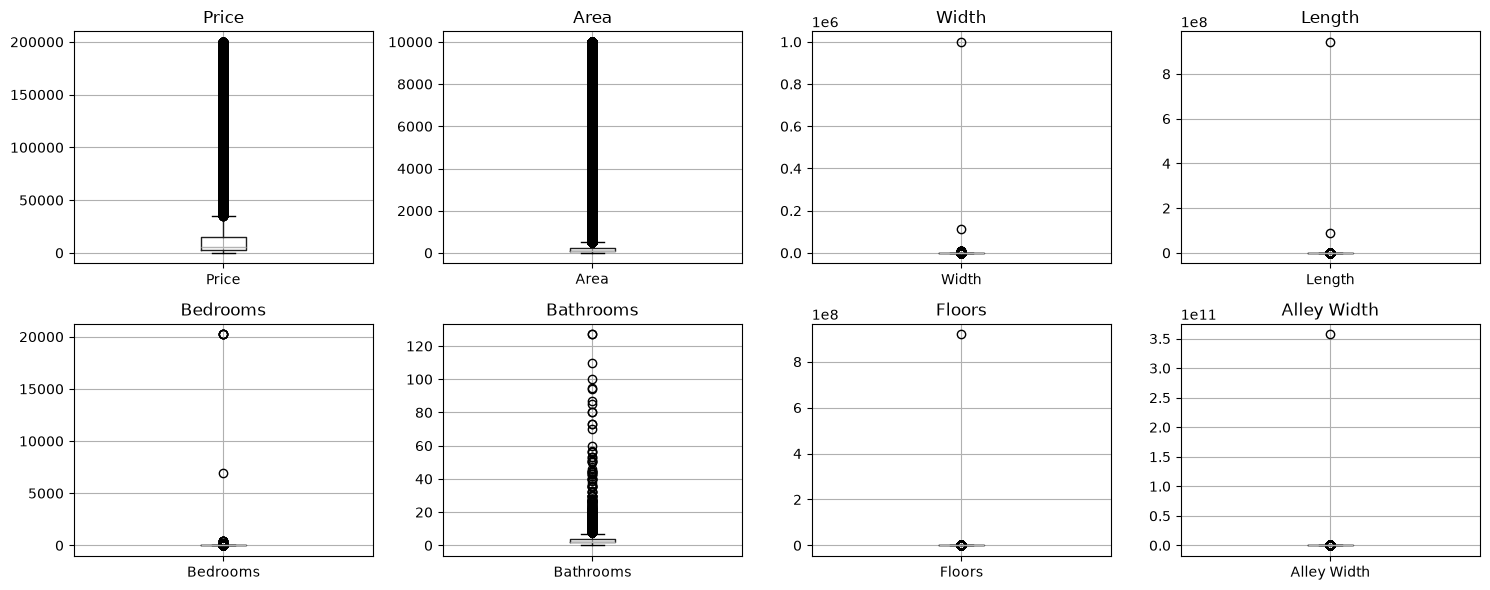

In [8]:
num_cols_raw = ['Price', 'Area', 'Width', 'Length', 'Bedrooms', 'Bathrooms', 'Floors', 'Alley Width']
Q1, Q3 = df[num_cols_raw].quantile(0.25), df[num_cols_raw].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = ((df[num_cols_raw] < Q1 - 1.5*IQR) | (df[num_cols_raw] > Q3 + 1.5*IQR)).sum()
print('IQR-rule outlier counts:')
print(iqr_outliers)

fig, ax = plt.subplots(2, 4, figsize=(15, 6))
for a, c in zip(ax.ravel(), num_cols_raw):
    df.boxplot(column=c, ax=a); a.set_title(c)
plt.tight_layout(); plt.show()

**Decision.** `Price` / `Area` / `Width` / `Length` have long right tails, but these
are genuine high-end listings (impossible values already removed in section 8). Keep
the rows; model **`log1p(Price)`** (section 12) to compress the tail, and cap
`Area` / `Width` / `Length` / `Alley Width` at the 99th percentile (section 13).

## 10. Exploratory data analysis

Organised in three subsections, **one figure (or one closely-related pair) per block**,
each block followed by an *Observation / Interpretation / ML implication* note:

- **10.1 Distributions** — the target and the individual features.
- **10.2 Relationships & correlation** — each feature against the target, then the full
  correlation analysis (numeric Pearson *and* categorical correlation-ratio η²).
- **10.3 Supporting analyses** — missingness, skew, and the per-type area effect.

All plots use the cleaned frame from sections 7–8; scatter plots are on a random sample.

### 10.1 Distributions


In [9]:
# derived columns used throughout section 10
df['price_log'] = np.log1p(df['Price'])
df['price_per_m2'] = df['Price'] / df['Area']
df['area_log'] = np.log1p(df['Area'])

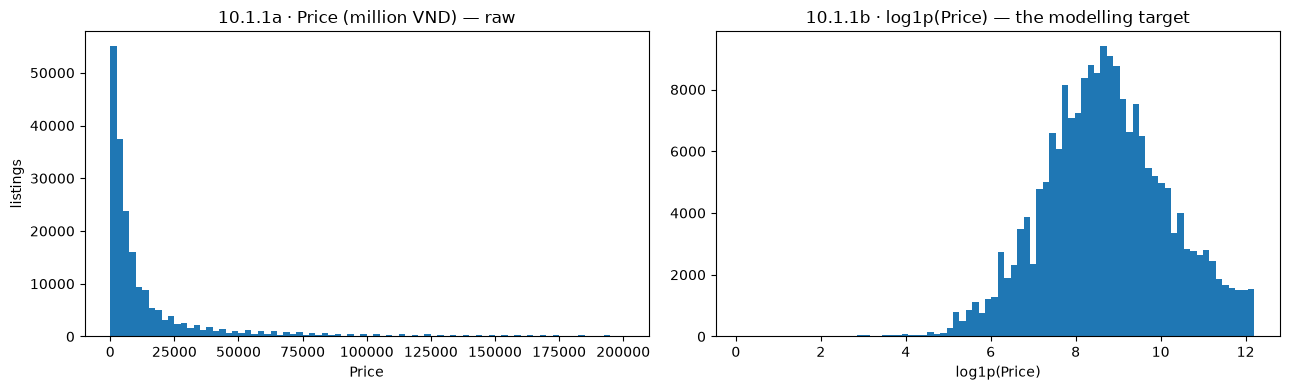

Price skew  : 3.36
log1p skew  : -0.07


In [10]:
# ---- 10.1.1 · target distribution: raw Price vs log1p(Price) ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df['Price'], bins=80)
ax[0].set_title('10.1.1a · Price (million VND) — raw')
ax[0].set_xlabel('Price'); ax[0].set_ylabel('listings')
ax[1].hist(df['price_log'], bins=80)
ax[1].set_title('10.1.1b · log1p(Price) — the modelling target')
ax[1].set_xlabel('log1p(Price)')
plt.tight_layout(); plt.show()

print('Price skew  :', round(df['Price'].skew(), 2))
print('log1p skew  :', round(df['price_log'].skew(), 2))

**Observation.** Raw `Price` is extreme right-skew — most listings sit at 2–5 tỷ with a
thin tail to ~200 tỷ (skew ≈ 3.4). `log1p(Price)` is close to symmetric (skew ≈ 0).
**Interpretation.** Price behaves multiplicatively, not additively.
**ML implication.** The model is trained on `log1p(Price)` and the metrics are reported
back on the million-VND scale with `expm1` (sections 12, 16, 19).

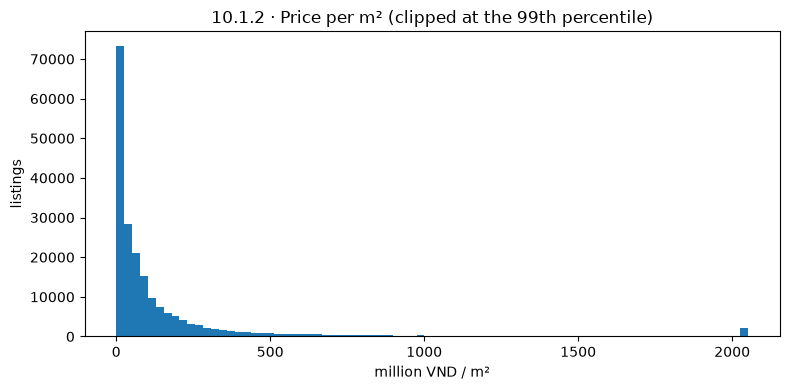

count    201654.0
mean        158.8
std         475.7
min           0.0
50%          50.0
90%         346.2
99%        2052.6
max       79000.0


In [11]:
# ---- 10.1.2 · unit price (Price per m²) ----
pm2 = df['price_per_m2'].clip(upper=df['price_per_m2'].quantile(0.99))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pm2, bins=80)
ax.set_title('10.1.2 · Price per m² (clipped at the 99th percentile)')
ax.set_xlabel('million VND / m²'); ax.set_ylabel('listings')
plt.tight_layout(); plt.show()

print(df['price_per_m2'].describe(percentiles=[.5, .9, .99]).round(1).to_string())

**Observation.** Unit price is also right-skewed; the median is a few tens of
million VND/m² with a long upper tail (central-district listings).
**Interpretation.** `Price / Area` is not a stable constant — it varies strongly with
location and property type, so it cannot replace the model.
**ML implication.** `price_per_m2` is used only for EDA and for the API response; it is
**not** a training feature (it is a function of the target).

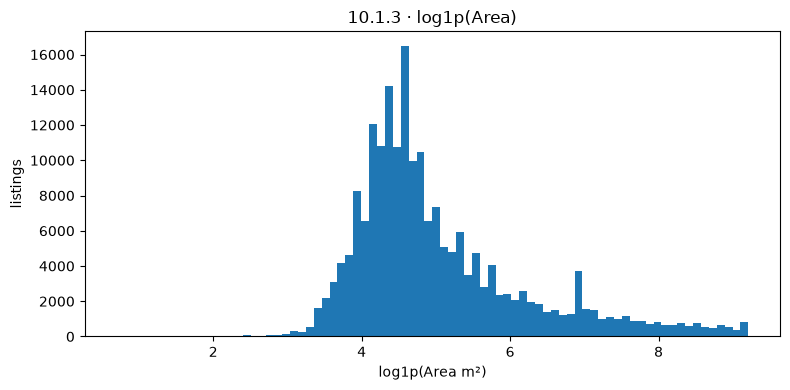

Area skew        : 5.11
log1p(Area) skew : 1.32


In [12]:
# ---- 10.1.3 · log1p(Area) ----
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['area_log'], bins=80)
ax.set_title('10.1.3 · log1p(Area)')
ax.set_xlabel('log1p(Area m²)'); ax.set_ylabel('listings')
plt.tight_layout(); plt.show()

print('Area skew        :', round(df['Area'].skew(), 2))
print('log1p(Area) skew :', round(df['area_log'].skew(), 2))

**Observation.** Raw `Area` is heavily right-skewed (skew ≈ 5); on the `log1p` scale it
is roughly bell-shaped (skew ≈ 1.3) after the section-8 domain filter.
**Interpretation.** A few very large plots would otherwise dominate distance- and
error-based models.
**ML implication.** `Area` (and `Width` / `Length` / `Alley Width`) are capped at the
99th percentile in section 13, and every numeric column is standardised in section 15.

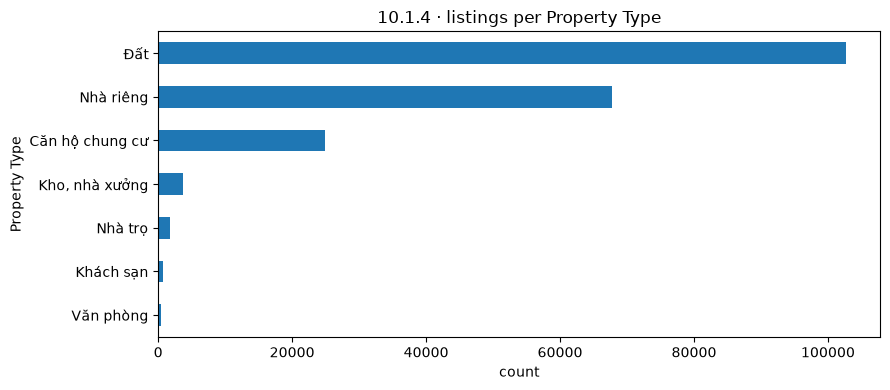

Property Type
Đất                102636
Nhà riêng           67790
Căn hộ chung cư     24860
Kho, nhà xưởng       3635
Nhà trọ              1700
Khách sạn             649
Văn phòng             384


In [13]:
# ---- 10.1.4 · number of listings per property type ----
fig, ax = plt.subplots(figsize=(9, 4))
df['Property Type'].value_counts().plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('10.1.4 · listings per Property Type'); ax.set_xlabel('count')
plt.tight_layout(); plt.show()

print(df['Property Type'].value_counts().to_string())

**Observation.** `Đất` (land) and `Nhà riêng` (houses) make up the large majority of
listings; `Khách sạn`, `Văn phòng`, `Nhà trọ` have only a few hundred rows each.
**Interpretation.** The class mix is very unbalanced, and the rare types are exactly the
ones the model will struggle on (section 20).
**ML implication.** `Property Type` is one-hot encoded; the rare levels stay as their own
columns (7 values, well above the `min_frequency` threshold).

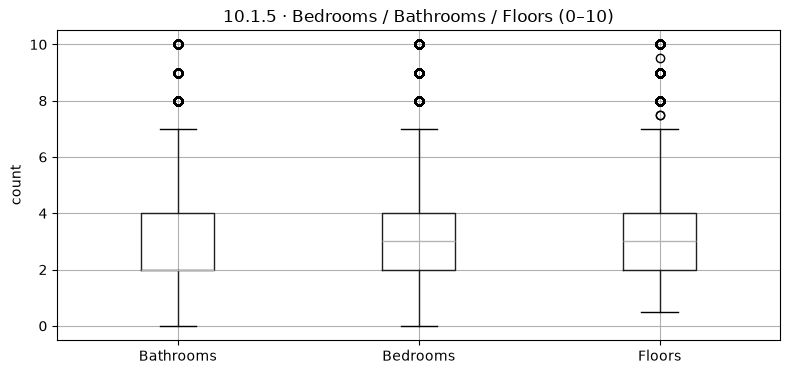

       Bedrooms  Bathrooms       Floors
count   60522.0    35314.0      46087.0
mean        5.2        3.0      19969.1
std       186.0        3.0    4281602.0
min         0.0        0.0        -11.0
25%         2.0        2.0          2.0
50%         3.0        2.0          3.0
75%         4.0        4.0          4.0
max     20224.0      127.0  919168799.0


In [14]:
# ---- 10.1.5 · room / floor counts (0–10, where recorded) ----
room = df[['Bedrooms', 'Bathrooms', 'Floors']].melt(var_name='feature', value_name='n')
room = room[room['n'].between(0, 10)]
fig, ax = plt.subplots(figsize=(8, 4))
room.boxplot(column='n', by='feature', ax=ax)
ax.set_title('10.1.5 · Bedrooms / Bathrooms / Floors (0–10)')
ax.set_xlabel(''); ax.set_ylabel('count'); plt.suptitle('')
plt.tight_layout(); plt.show()

print(df[['Bedrooms', 'Bathrooms', 'Floors']].describe().round(1).to_string())

**Observation.** When present, `Bedrooms` / `Bathrooms` / `Floors` cluster tightly at
2–4; but they are recorded for only ~30% of rows (mostly built property, not land).
**Interpretation.** These counts are meaningful for houses / apartments and largely
absent for land — the missingness itself is informative.
**ML implication.** Section 13 median-imputes the value **and** adds a
`<column>_missing` 0/1 indicator; see 10.3.2 for the by-type breakdown.

### 10.2 Relationships & correlation

Each feature against the target (10.2.1–10.2.3), then the full correlation analysis:
numeric Pearson (10.2.4) and categorical correlation-ratio η² (10.2.5).

In [15]:
# correlation ratio (eta^2): share of variance in `values` explained by a categorical grouping
def correlation_ratio(categories, values):
    cats = categories.astype('category').cat.codes.values
    y = values.values
    ss_total = ((y - y.mean()) ** 2).sum()
    ss_between = sum(len(y[cats == k]) * (y[cats == k].mean() - y.mean()) ** 2
                     for k in np.unique(cats))
    return ss_between / ss_total if ss_total > 0 else 0.0

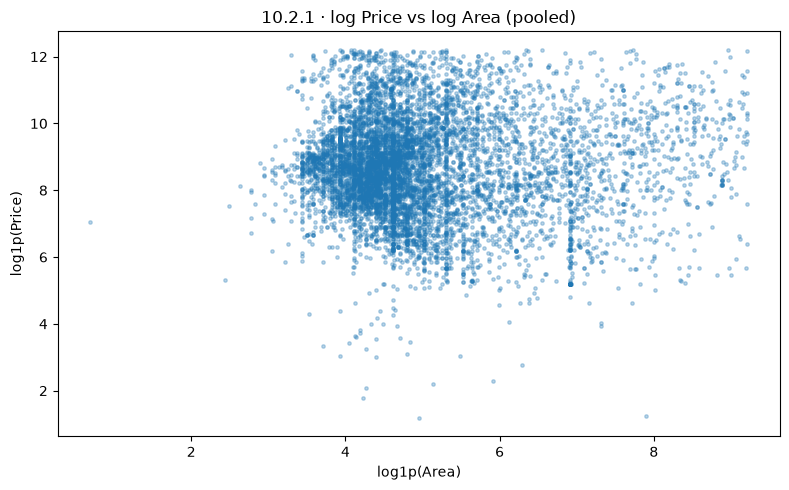

pooled Pearson r(log Area, log Price) = 0.017


In [16]:
# ---- 10.2.1 · log Price vs log Area, all property types pooled ----
samp = df.sample(min(8000, len(df)), random_state=RANDOM_SEED)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(samp['area_log'], samp['price_log'], s=6, alpha=0.3)
ax.set_title('10.2.1 · log Price vs log Area (pooled)')
ax.set_xlabel('log1p(Area)'); ax.set_ylabel('log1p(Price)')
plt.tight_layout(); plt.show()

print('pooled Pearson r(log Area, log Price) =',
      round(df['area_log'].corr(df['price_log']), 3))

**Observation.** The pooled cloud shows only a **weak** positive trend — Pearson r ≈ 0.02
— with very wide vertical spread at every area.
**Interpretation.** Taken over all listings at once, area barely predicts price. This is
misleading (see 10.2.3 / 10.3.4): the land-vs-built mix cancels the effect out.
**ML implication.** Area cannot be used as a standalone linear predictor; it needs the
property-type context.

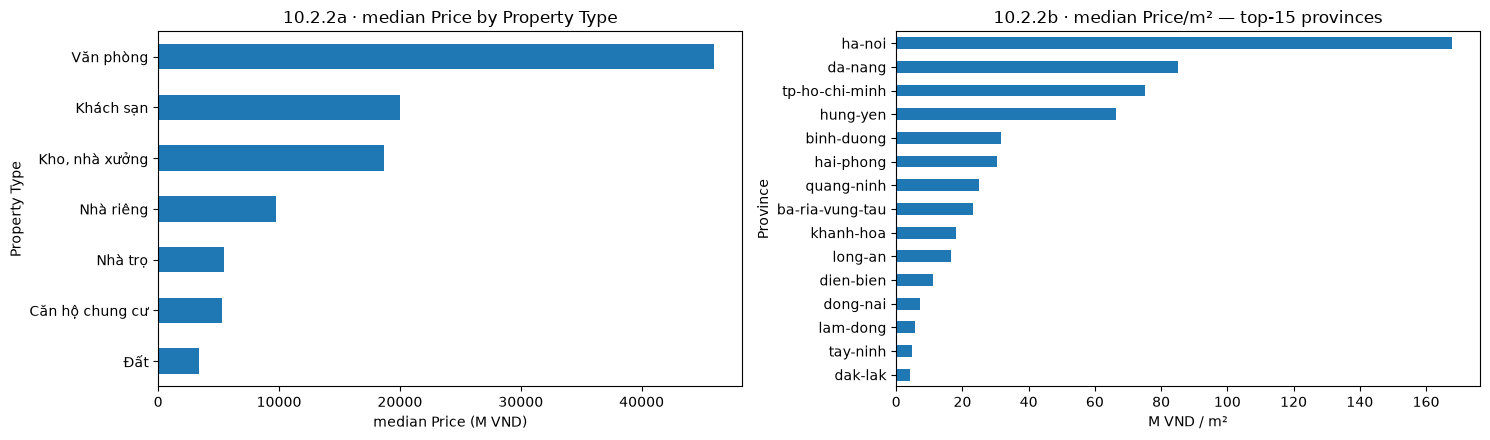

In [17]:
# ---- 10.2.2 · price level by property type and by province ----
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
df.groupby('Property Type')['Price'].median().sort_values().plot(kind='barh', ax=ax[0])
ax[0].set_title('10.2.2a · median Price by Property Type'); ax[0].set_xlabel('median Price (M VND)')

top_prov = df['Province'].value_counts().head(15).index
(df[df['Province'].isin(top_prov)]
   .groupby('Province')['price_per_m2'].median().sort_values()
   .plot(kind='barh', ax=ax[1]))
ax[1].set_title('10.2.2b · median Price/m² — top-15 provinces'); ax[1].set_xlabel('M VND / m²')
plt.tight_layout(); plt.show()

**Observation.** Median price differs several-fold across property types, and median
Price/m² varies ~5× across provinces (HCMC / Hà Nội / Đà Nẵng highest, rural provinces
lowest).
**Interpretation.** Property type and province each set the *level* of price; area then
scales it within that level.
**ML implication.** Both are one-hot encoded (section 15); they are expected to be the
strongest features (confirmed by 10.2.5 and section 20's feature importances).

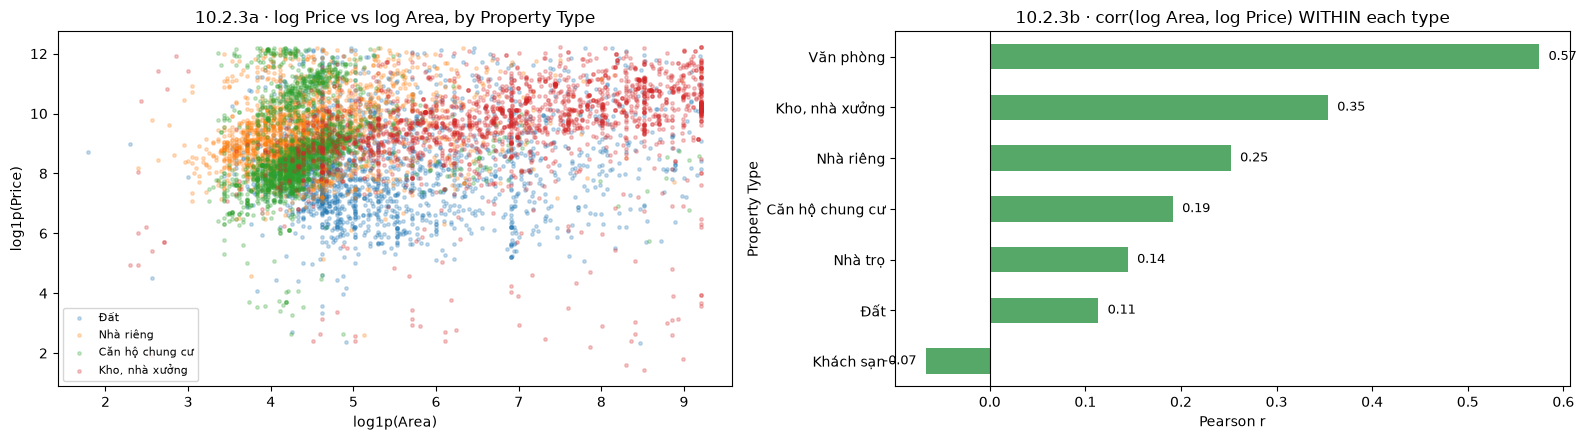

In [18]:
# ---- 10.2.3 · the same relationship, split by property type ----
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
for pt in df['Property Type'].value_counts().head(4).index:
    d = df[df['Property Type'] == pt].sample(
        min(2000, (df['Property Type'] == pt).sum()), random_state=RANDOM_SEED)
    ax[0].scatter(d['area_log'], d['price_log'], s=6, alpha=0.25, label=pt)
ax[0].legend(fontsize=8)
ax[0].set_title('10.2.3a · log Price vs log Area, by Property Type')
ax[0].set_xlabel('log1p(Area)'); ax[0].set_ylabel('log1p(Price)')

within = (df.groupby('Property Type')
            .apply(lambda g: g['area_log'].corr(g['price_log']))
            .sort_values())
within.plot(kind='barh', ax=ax[1], color='#55A868')
for i, v in enumerate(within.values):
    ax[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}', va='center',
               ha='left' if v >= 0 else 'right', fontsize=9)
ax[1].axvline(0, color='k', lw=0.8)
ax[1].set_title('10.2.3b · corr(log Area, log Price) WITHIN each type')
ax[1].set_xlabel('Pearson r')
plt.tight_layout(); plt.show()

**Observation.** Split by type, the Area→Price slope is positive for the built types
(`Nhà riêng`, `Căn hộ chung cư`, `Văn phòng`), near-flat for `Đất`, ≈ 0 pooled (10.2.1).
**ML implication.** Keep `Area` but combine it with `Property Type`; tree ensembles do
this natively (per-type slopes in 10.3.4).

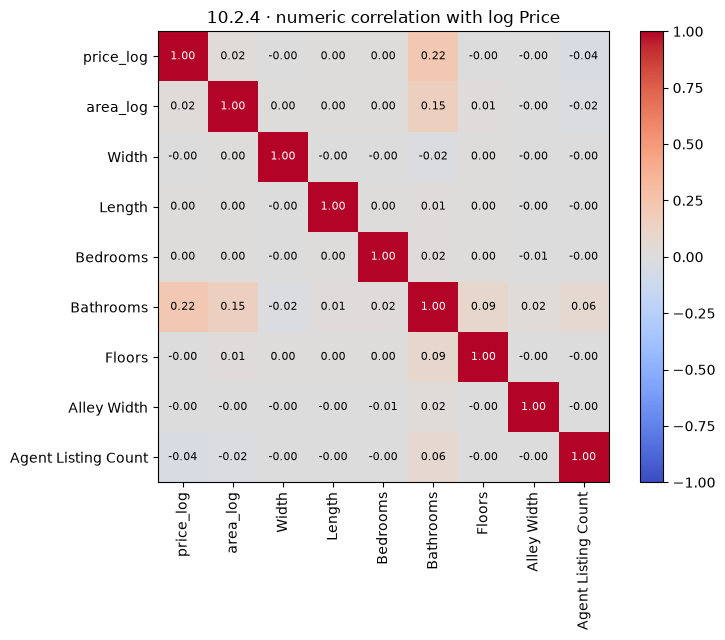

|r| with log Price:
Bathrooms              0.215
Agent Listing Count    0.040
area_log               0.017
Bedrooms               0.005
Floors                 0.004
Alley Width            0.004
Width                  0.004
Length                 0.003


In [19]:
# ---- 10.2.4 · numeric correlation with log Price (Pearson) ----
num_corr_cols = ['price_log', 'area_log', 'Width', 'Length', 'Bedrooms',
                 'Bathrooms', 'Floors', 'Alley Width', 'Agent Listing Count']
cm = df[num_corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(cm, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_corr_cols))); ax.set_xticklabels(num_corr_cols, rotation=90)
ax.set_yticks(range(len(num_corr_cols))); ax.set_yticklabels(num_corr_cols)
for r in range(len(num_corr_cols)):
    for c in range(len(num_corr_cols)):
        ax.text(c, r, f'{cm.iat[r, c]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(cm.iat[r, c]) > 0.5 else 'black')
ax.set_title('10.2.4 · numeric correlation with log Price')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print('|r| with log Price:')
print(cm['price_log'].drop('price_log').abs().sort_values(ascending=False).round(3).to_string())

**Observation.** On the pooled data the strongest numeric correlation with `log Price` is
only `Bathrooms` ≈ 0.22; `area_log` ≈ 0.02. No pair of features has |r| ≈ 1.
**Interpretation.** The weak numbers are a pooling artefact (10.2.1), not evidence that
the features are useless. The absence of |r| ≈ 1 means no numeric column is redundant.
**ML implication.** Keep all numeric features; no need to drop any for collinearity. A
numeric-only view understates the dataset — see 10.2.5.

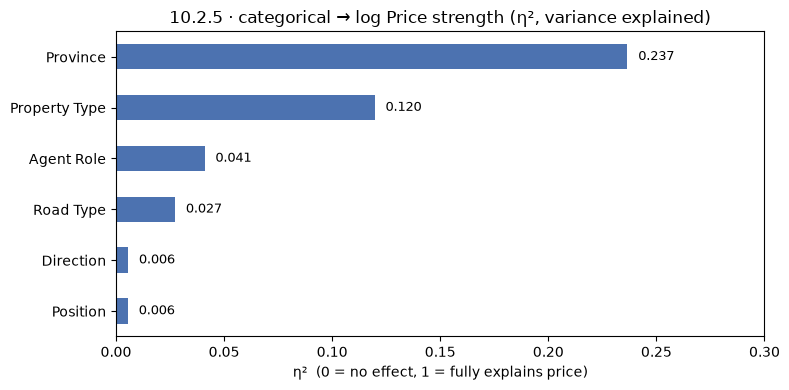

Province         0.237
Property Type    0.120
Agent Role       0.041
Road Type        0.027
Direction        0.006
Position         0.006


In [20]:
# ---- 10.2.5 · categorical → log Price strength (correlation ratio η²) ----
cat_cols = ['Property Type', 'Province', 'Position', 'Direction', 'Road Type', 'Agent Role']
eta = pd.Series({c: correlation_ratio(df[c].fillna('Unknown'), df['price_log'])
                for c in cat_cols}).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
eta.plot(kind='barh', ax=ax, color='#4C72B0')
for i, v in enumerate(eta.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlim(0, max(0.3, eta.max() * 1.25))
ax.set_title('10.2.5 · categorical → log Price strength (η², variance explained)')
ax.set_xlabel('η²  (0 = no effect, 1 = fully explains price)')
plt.tight_layout(); plt.show()

print(eta.sort_values(ascending=False).round(3).to_string())

**Observation.** η² (comparable to r²): `Province` ≈ 0.24, `Property Type` ≈ 0.12 —
each explains more price variance than any numeric feature; `Direction` / `Position` /
`Road Type` / `Agent Role` < 0.05.
**ML implication.** One-hot `Property Type` and `Province` / `district`; the low-η²
categoricals are the first drop candidates if `d` must shrink.

### 10.3 Supporting analyses for the modelling choices

Four short views, each justifying one later decision:

| # | View | Justifies |
|---|---|---|
| 10.3.1 | missing values per column | which columns to impute vs drop |
| 10.3.2 | missing values by property type | the `*_missing` indicator features (section 13) |
| 10.3.3 | skew before/after `log1p` + QQ-plot | the `log1p(Price)` target and the p99 caps |
| 10.3.4 | `log Price` vs `log Area` per property type | why the model needs area×type, not area alone |

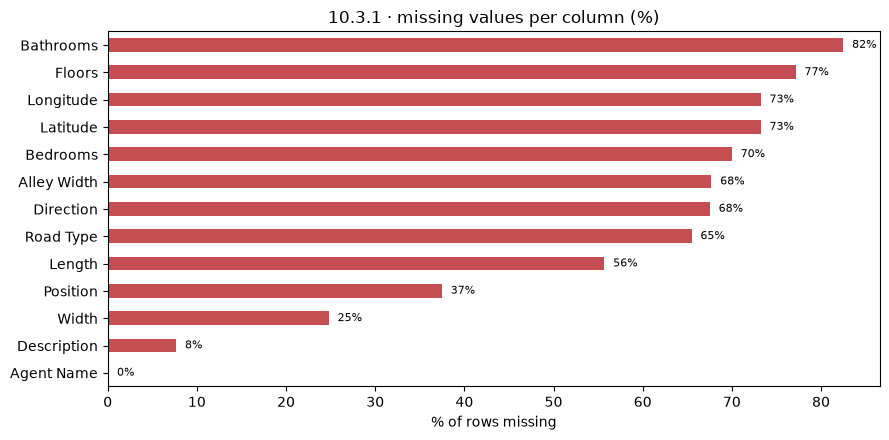

Bathrooms      82.5
Floors         77.1
Longitude      73.2
Latitude       73.2
Bedrooms       70.0
Alley Width    67.7
Direction      67.5
Road Type      65.5
Length         55.7
Position       37.5
Width          24.8
Description     7.7
Agent Name      0.0


In [21]:
# ---- 10.3.1 · how much is missing, per column ----
miss_pct = (df.isna().mean() * 100)
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
miss_pct.plot(kind='barh', ax=ax, color='#C44E52')
ax.invert_yaxis()
ax.set_title('10.3.1 · missing values per column (%)')
ax.set_xlabel('% of rows missing')
for i, v in enumerate(miss_pct.values):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

print(miss_pct.round(1).to_string())

**Observation.** `Bathrooms` ≈ 83%, `Floors` ≈ 77%, `Bedrooms` ≈ 70%,
`Alley Width` / `Direction` / `Road Type` ≈ 65–68%, `Latitude` / `Longitude` ≈ 73% of
rows are missing; `Area` is essentially complete after section 8.
**Interpretation.** More than half the candidate columns are majority-missing, so
row-dropping is not an option — it would delete most of the data.
**ML implication.** Numeric columns are median-imputed inside the pipeline (section 15);
`Latitude` / `Longitude` are too sparse to impute meaningfully and are dropped (province
and district cover location instead).

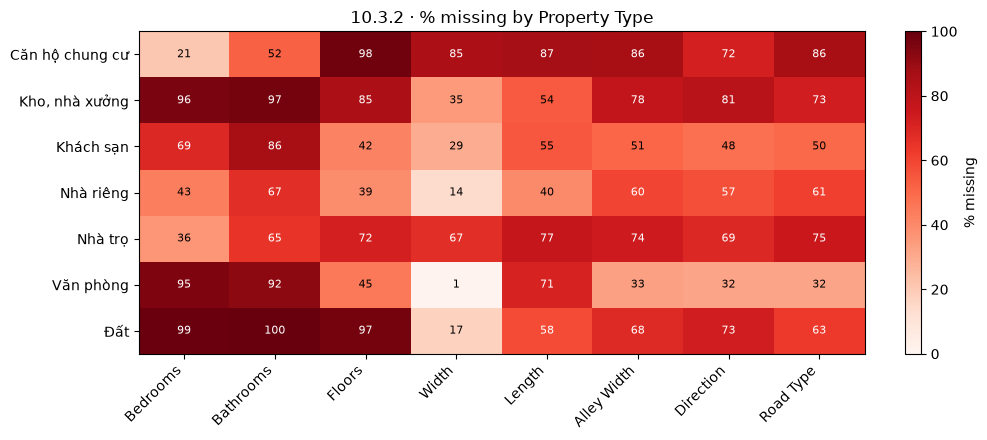

In [22]:
# ---- 10.3.2 · is the missingness random? break it down by property type ----
flag_cols = ['Bedrooms', 'Bathrooms', 'Floors', 'Width', 'Length',
             'Alley Width', 'Direction', 'Road Type']
by_type = (df.groupby('Property Type')[flag_cols]
             .apply(lambda g: g.isna().mean() * 100).round(0))

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(by_type.values, cmap='Reds', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(flag_cols))); ax.set_xticklabels(flag_cols, rotation=45, ha='right')
ax.set_yticks(range(len(by_type.index))); ax.set_yticklabels(by_type.index)
for r in range(by_type.shape[0]):
    for cc in range(by_type.shape[1]):
        val = by_type.values[r, cc]
        ax.text(cc, r, f'{val:.0f}', ha='center', va='center', fontsize=8,
                color='white' if val > 55 else 'black')
ax.set_title('10.3.2 · % missing by Property Type')
plt.colorbar(im, ax=ax, fraction=0.046, label='% missing')
plt.tight_layout(); plt.show()

**Observation.** Missingness is structural: `Đất` 99% missing `Bedrooms` / 100%
`Bathrooms`; `Căn hộ chung cư` 98% missing `Floors`; `Nhà riêng` lowest overall.
**ML implication.** Median-imputing alone loses this signal → section 13 adds
`Bedrooms_missing` / `Bathrooms_missing` / `Floors_missing` indicator columns.

column  skew_raw  skew_log1p
 Price      3.36       -0.07
  Area      5.11        1.32
 Width    380.48        2.38
Length    295.32        1.72


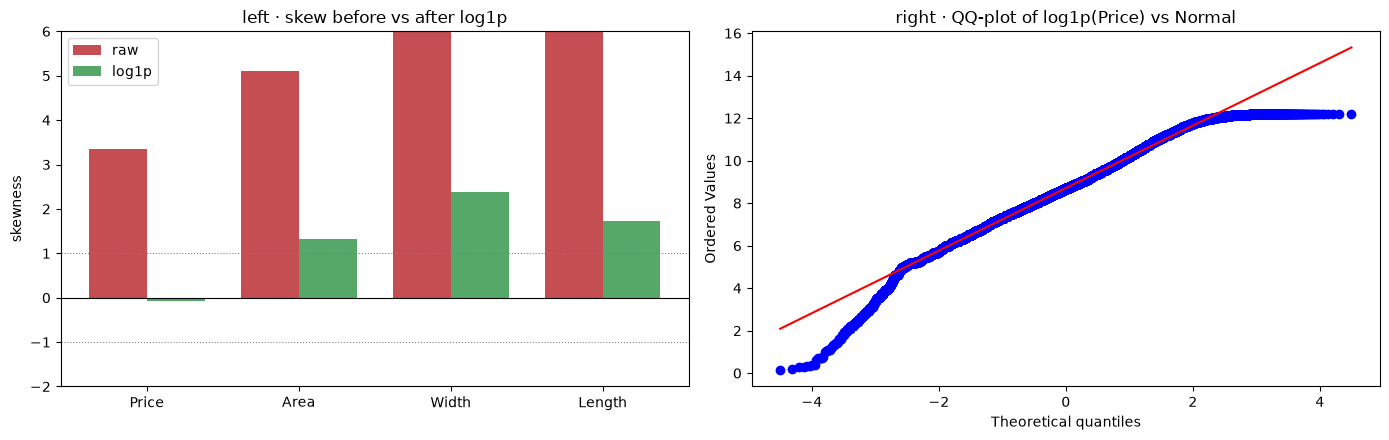

In [23]:
# ---- 10.3.3 · skew of the numeric columns, and what log1p does to it ----
from scipy import stats

skew_cols = ['Price', 'Area', 'Width', 'Length']
rows = [[c, stats.skew(df[c].dropna()), stats.skew(np.log1p(df[c].dropna()))] for c in skew_cols]
skew_tbl = pd.DataFrame(rows, columns=['column', 'skew_raw', 'skew_log1p']).round(2)
print(skew_tbl.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(skew_cols)); w = 0.38
ax[0].bar(x - w/2, skew_tbl['skew_raw'],   w, label='raw',   color='#C44E52')
ax[0].bar(x + w/2, skew_tbl['skew_log1p'], w, label='log1p', color='#55A868')
ax[0].set_xticks(x); ax[0].set_xticklabels(skew_cols)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].axhline(1, color='grey', ls=':', lw=0.8); ax[0].axhline(-1, color='grey', ls=':', lw=0.8)
ax[0].set_ylim(-2, 6)                      # clip the ~380 raw Width/Length skew for readability
ax[0].set_ylabel('skewness'); ax[0].set_title('left · skew before vs after log1p'); ax[0].legend()

stats.probplot(df['price_log'], dist='norm', plot=ax[1])
ax[1].set_title('right · QQ-plot of log1p(Price) vs Normal')
plt.tight_layout(); plt.show()

**Observation.** Raw skew: `Price` 3.4, `Area` 5.1, `Width` / `Length` > 250. After
`log1p` all fall to ≈ ±1.3, `log1p(Price)` ≈ 0; the QQ-plot is near-Normal except in
the far tails.
**ML implication.** Train on `log1p(Price)`, score after `expm1`; cap
`Area` / `Width` / `Length` / `Alley Width` at the 99th percentile (section 13).

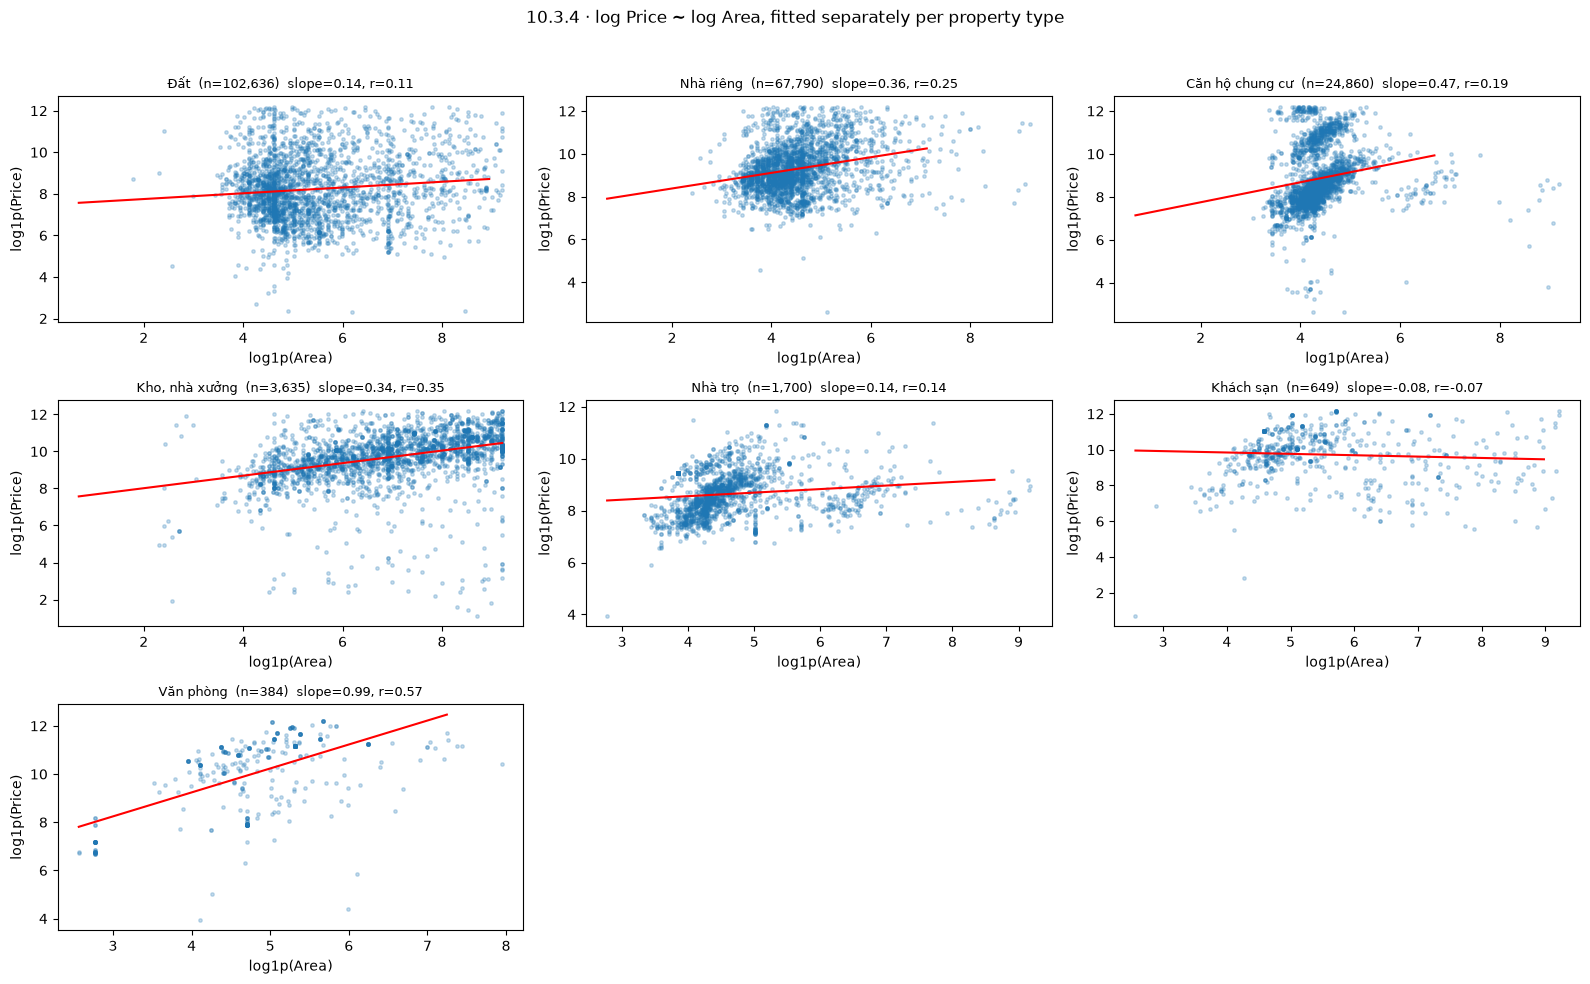

slope of log Price ~ log Area, by Property Type:
  Văn phòng          n=   384  slope= 0.99  r= 0.57
  Căn hộ chung cư    n= 24860  slope= 0.47  r= 0.19
  Nhà riêng          n= 67790  slope= 0.36  r= 0.25
  Kho, nhà xưởng     n=  3635  slope= 0.34  r= 0.35
  Đất                n=102636  slope= 0.14  r= 0.11
  Nhà trọ            n=  1700  slope= 0.14  r= 0.14
  Khách sạn          n=   649  slope=-0.08  r=-0.07


In [24]:
# ---- 10.3.4 · does Area predict Price WITHIN each property type? ----
types = [t for t in df['Property Type'].value_counts().index
         if (df['Property Type'] == t).sum() >= 200]

n = len(types); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(16, 3.2 * nrow), squeeze=False)
slopes = {}
for k, t in enumerate(types):
    a = ax[k // ncol][k % ncol]
    g = df[df['Property Type'] == t]
    gs = g.sample(min(2500, len(g)), random_state=RANDOM_SEED)
    a.scatter(gs['area_log'], gs['price_log'], s=6, alpha=0.25)
    b, a0, r, _, _ = stats.linregress(g['area_log'], g['price_log'])
    slopes[t] = (b, r, len(g))
    xs = np.linspace(g['area_log'].min(), g['area_log'].quantile(0.99), 50)
    a.plot(xs, a0 + b * xs, 'r-', lw=1.5)
    a.set_title(f'{t}  (n={len(g):,})  slope={b:.2f}, r={r:.2f}', fontsize=9)
    a.set_xlabel('log1p(Area)'); a.set_ylabel('log1p(Price)')
for k in range(n, nrow * ncol):
    ax[k // ncol][k % ncol].axis('off')
plt.suptitle('10.3.4 · log Price ~ log Area, fitted separately per property type', y=1.02)
plt.tight_layout(); plt.show()

print('slope of log Price ~ log Area, by Property Type:')
for t, (b, r, m) in sorted(slopes.items(), key=lambda kv: -kv[1][0]):
    print(f'  {t:18s} n={m:6d}  slope={b:5.2f}  r={r:5.2f}')

**Observation.** Per-type `log Area` → `log Price` slope: `Văn phòng` 0.99,
`Căn hộ chung cư` 0.47, `Nhà riêng` 0.36, `Kho` 0.34, `Đất` / `Nhà trọ` 0.14,
`Khách sạn` ≈ 0. Pooled slope ≈ 0 (10.2.1) — Simpson's paradox.
**ML implication.** Linear models (additive `Area` only) underperform; tree ensembles
split on `Property Type` then `Area`. Matches the section 18 ranking (RF / XGBoost > Linear / Ridge).

## 11. Feature types

In [25]:
feature_types = {
    # --- numerical ---
    'Area': 'numerical', 'Width': 'numerical', 'Length': 'numerical',
    'Bedrooms': 'numerical (count)', 'Bathrooms': 'numerical (count)',
    'Floors': 'numerical (count)', 'Alley Width': 'numerical',
    'Agent Listing Count': 'numerical (count)',
    # --- categorical (one-hot) ---
    'Property Type': 'categorical', 'Position': 'categorical',
    'Direction': 'categorical', 'Road Type': 'categorical',
    'Province': 'categorical (63 levels)', 'Agent Role': 'categorical',
    # --- engineered from text (section 13) ---
    'Location': 'text -> parsed into the district feature, then dropped',
    # --- target ---
    'Price': 'target (continuous, million VND)',
    # --- dropped ---
    'Title': 'DROP — free text, leaks Price',
    'Description': 'DROP — free text, not used',
    'Listing ID': 'DROP — identifier (used only for dedupe)',
    'VIP Account': 'DROP — constant',
    'Avatar': 'DROP — not informative',
    'Agent Name': 'DROP — 28k unique, high-cardinality noise',
    'Property Type Slug': 'DROP — duplicate of Property Type',
    'Last Updated': 'DROP — free-text recency string',
    'Scraped At': 'DROP — scrape timestamp',
    'Last Updated Date': 'DROP — timestamp',
    'Latitude': 'DROP — 68% missing', 'Longitude': 'DROP — 68% missing',
}
pd.Series(feature_types, name='role')

Area                                                           numerical
Width                                                          numerical
Length                                                         numerical
Bedrooms                                               numerical (count)
Bathrooms                                              numerical (count)
Floors                                                 numerical (count)
Alley Width                                                    numerical
Agent Listing Count                                    numerical (count)
Property Type                                                categorical
Position                                                     categorical
Direction                                                    categorical
Road Type                                                    categorical
Province                                         categorical (63 levels)
Agent Role                                         

**Result.** 11 numeric features (incl. 3 `_missing` flags), 7 one-hot categoricals
(`Property Type`, `Position`, `Direction`, `Road Type`, `Province`, `Agent Role`,
`district`), 1 continuous target, 13 columns dropped (identifiers, constants, free
text, `Property Type Slug` duplicate, sparse coords).

## 12. Data representation

```
CSV  ->  DataFrame  ->  clean feature frame  ->  ColumnTransformer (impute + scale + one-hot)  ->  X  ->  model
```

The cell below prints one raw listing and the feature vector it becomes, together with
the DataFrame shape, the final `X` shape and its dtype.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# minimal engineered frame just for this demo (full version in section 13)
NUM_DEMO = ['Area', 'Width', 'Length', 'Bedrooms', 'Bathrooms', 'Floors', 'Alley Width']
CAT_DEMO = ['Property Type', 'Position', 'Direction', 'Road Type', 'Province', 'Agent Role']

demo_df = df[NUM_DEMO + CAT_DEMO].copy()
for c in CAT_DEMO:
    demo_df[c] = demo_df[c].fillna('Unknown')
y_demo = np.log1p(df['Price'].values)   # model target = log1p(Price)

demo_prep = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), NUM_DEMO),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), CAT_DEMO),
])
X_demo = demo_prep.fit_transform(demo_df)

print('one RAW listing (selected columns):')
print(df.iloc[0][['Title', 'Price', 'Area', 'Property Type', 'Location']].to_dict())
print('\nsame listing as a FEATURE VECTOR x (first 15 dims of the imputed+scaled+one-hot row):')
row0 = X_demo[0].toarray().ravel() if hasattr(X_demo, 'toarray') else X_demo[0]
print(np.round(row0[:15], 3))
print('\nDataFrame shape at this point :', df.shape, ' (after sections 7-8 cleaning)')
print('feature matrix X shape   :', X_demo.shape, '  # X in R^{N x d}')
print('target vector y shape    :', y_demo.shape, '  # y in R^N  (log1p million VND)')
print('dtype of X               :', X_demo.dtype)
print('one API request is       :  R^{1 x d}   (a single listing)')

one RAW listing (selected columns):
{'Title': 'Bán nhà 192m² 2 tỷ tại Phường Mỹ Hòa Thành phố Long Xuyên phía sau nhà có thêm mảnh vườn nhỏ tâm 150m²', 'Price': 2000.0, 'Area': 192.0, 'Property Type': 'Nhà riêng', 'Location': 'Phường Long Xuyên,An Giang(Mới)'}

same listing as a FEATURE VECTOR x (first 15 dims of the imputed+scaled+one-hot row):
[-0.223 -0.005 -0.002 -0.007 -0.133 -0.002 -0.002  0.     0.     0.
  1.     0.     0.     0.     0.   ]

DataFrame shape at this point : (201654, 31)  (after sections 7-8 cleaning)
feature matrix X shape   : (201654, 92)   # X in R^{N x d}
target vector y shape    : (201654,)   # y in R^N  (log1p million VND)
dtype of X               : float64
one API request is       :  R^{1 x d}   (a single listing)


## 13. Feature engineering

In [27]:
def parse_district(loc):
    """'Đường X,Phường Y,Quận Z,Tỉnh(Mới)' -> district.
    Prefer a Quận/Huyện/Thị xã/Thành phố token; fall back to the ward
    (Phường/Xã/Thị trấn/Đặc khu); 'Unknown' if neither is present.
    Ward itself is NOT used as a feature: ~4,600 levels is mostly noise."""
    if not isinstance(loc, str):
        return 'Unknown'
    parts = [p.strip() for p in loc.replace('(Mới)', '').split(',') if p.strip()]
    dist = next((p for p in parts if p.startswith(('Quận', 'Huyện', 'Thị xã', 'Thành phố', 'TP.', 'TP '))), None)
    if dist:
        return dist
    return next((p for p in parts if p.startswith(('Phường', 'Xã', 'Thị trấn', 'Đặc khu'))), 'Unknown')


def engineer(frame):
    out = frame.copy()
    # 1. parsed location (district level only)
    out['district'] = out['Location'].apply(parse_district)
    # 2. missing-indicator flags for the >50%-missing counts
    for c in ['Bedrooms', 'Bathrooms', 'Floors']:
        out[c + '_missing'] = out[c].isna().astype(int)
    # 3. cap extreme size (99th pct) so distance/linear models aren't dominated
    for c in ['Area', 'Width', 'Length', 'Alley Width']:
        cap = out[c].quantile(0.99)
        out[c] = out[c].clip(upper=cap)
    # 4. fill categorical NaN with an explicit level
    for c in ['Position', 'Direction', 'Road Type']:
        out[c] = out[c].fillna('Unknown')
    return out


df_eng = engineer(df)

NUM_FEATURES = ['Area', 'Width', 'Length', 'Bedrooms', 'Bathrooms', 'Floors',
                'Alley Width', 'Agent Listing Count',
                'Bedrooms_missing', 'Bathrooms_missing', 'Floors_missing']
CAT_FEATURES = ['Property Type', 'Position', 'Direction', 'Road Type',
                'Province', 'Agent Role', 'district']
FEATURES = NUM_FEATURES + CAT_FEATURES

print('final raw feature count :', len(FEATURES))
print('numeric  :', NUM_FEATURES)
print('categoric:', CAT_FEATURES)
print('district levels        :', df_eng['district'].nunique(),
      '(rare ones folded by min_frequency in section 15)')
df_eng[FEATURES].head(3)

final raw feature count : 18
numeric  : ['Area', 'Width', 'Length', 'Bedrooms', 'Bathrooms', 'Floors', 'Alley Width', 'Agent Listing Count', 'Bedrooms_missing', 'Bathrooms_missing', 'Floors_missing']
categoric: ['Property Type', 'Position', 'Direction', 'Road Type', 'Province', 'Agent Role', 'district']
district levels        : 2082 (rare ones folded by min_frequency in section 15)


,Area,Width,Length,Bedrooms,Bathrooms,Floors,Alley Width,Agent Listing Count,Bedrooms_missing,Bathrooms_missing,Floors_missing,Property Type,Position,Direction,Road Type,Province,Agent Role,district
0,192.0,6.0,NaN,3.0,NaN,NaN,NaN,1.0,0,1,1,Nhà riêng,Unknown,Tây,Unknown,an-giang,Chính chủ,Phường Long Xuyên
1,1232.8,13.0,NaN,NaN,NaN,NaN,NaN,4.0,1,1,1,Nhà riêng,Unknown,Unknown,Unknown,an-giang,Chính chủ,Xã Vĩnh Xương
2,108.3,6.5,NaN,NaN,NaN,NaN,NaN,1.0,1,1,1,Nhà riêng,Unknown,Unknown,Unknown,an-giang,Chính chủ,Phường Tân Châu


**Engineered features.**

| Feature | Purpose |
|---|---|
| `district` (from `Location`) | admin-level location signal; `ward` (~4,600 levels) dropped as noise. |
| `Bedrooms_missing` / `Bathrooms_missing` / `Floors_missing` | encode "was this recorded?" (>70% missing, correlates with type). |
| 99th-pct cap on `Area` / `Width` / `Length` / `Alley Width` | bound the influence of a few huge lots. |

**Encoding.** One-hot for all categoricals (no natural order);
`OneHotEncoder(handle_unknown='ignore', min_frequency=50)` caps the column count.
Fitted pipeline (section 15): **`d = 404`**.

## 14. Train / validation / test split

In [28]:
from sklearn.model_selection import train_test_split

X_all = df_eng[FEATURES].copy()
y_all = np.log1p(df_eng['Price'].values)          # model target
y_all_vnd = df_eng['Price'].values                # kept for reporting on the real scale

X_train, X_tmp, y_train, y_tmp, _, y_tmp_vnd = train_test_split(
    X_all, y_all, y_all_vnd, test_size=0.30, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test, y_val_vnd, y_test_vnd = train_test_split(
    X_tmp, y_tmp, y_tmp_vnd, test_size=0.50, random_state=RANDOM_SEED)

print(f'train: {X_train.shape}   val: {X_val.shape}   test: {X_test.shape}   (~70/15/15)')

train: (141157, 18)   val: (30248, 18)   test: (30249, 18)   (~70/15/15)


**Data leakage.** Preprocessing is fitted on `X_train` only — if the imputer medians,
scaler stats or one-hot vocabulary saw validation/test rows, the reported error would
be optimistic. The split happens before any `.fit()`; the section-7 `Listing ID`
dedupe prevents the same property landing on both sides. `random_state` fixed.

## 15. Preprocessing pipeline

In [29]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=50, sparse_output=True)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUM_FEATURES),
    ('cat', categorical_pipe, CAT_FEATURES),
])

preprocessor.fit(X_train)                    # <-- fitted on TRAIN ONLY
X_train_pp = preprocessor.transform(X_train)
D_FEATURES = X_train_pp.shape[1]
print('preprocessed train shape:', X_train_pp.shape, '  # d =', D_FEATURES)
print('(numeric', len(NUM_FEATURES), '+ one-hot', D_FEATURES - len(NUM_FEATURES),
      'indicator columns, rare levels folded into an <infrequent> column)')

preprocessed train shape: (141157, 404)   # d = 404
(numeric 11 + one-hot 393 indicator columns, rare levels folded into an <infrequent> column)


## 16. Baseline model

In [30]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

LOG_CLIP = np.log1p(1_000_000)   # cap predictions at 1,000,000 million VND before expm1

def _to_vnd(y_log):
    """Invert the log1p target, guarding against overflow from wild linear extrapolation."""
    return np.expm1(np.clip(y_log, None, LOG_CLIP))

def regression_scores(y_true_log, y_pred_log):
    """Scores reported on the real VND scale (million VND)."""
    yt, yp = _to_vnd(y_true_log), _to_vnd(y_pred_log)
    mae = mean_absolute_error(yt, yp)
    mse = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    r2 = r2_score(yt, yp)
    mape = np.mean(np.abs((yt - yp) / np.clip(yt, 1e-6, None))) * 100
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE_%': mape}

base = Pipeline([('prep', preprocessor), ('reg', DummyRegressor(strategy='median'))])
base.fit(X_train, y_train)
base_scores = regression_scores(y_val, base.predict(X_val))
print('baseline (predict median log-price):')
for k, v in base_scores.items():
    print(f'  {k:7s}: {v:,.3f}')

baseline (predict median log-price):
  MAE    : 14,397.214
  MSE    : 1,035,863,080.861
  RMSE   : 32,184.827
  R2     : -0.131
  MAPE_% : 398.003


## 17. Model training

Five regression models are compared: Linear Regression, Ridge, Decision Tree, Random
Forest and Gradient Boosting (XGBoost). All share the identical `preprocessor` and the
same `X_train` / `y_train` (log-transformed target).

In [31]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
try:
    from xgboost import XGBRegressor
    _HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    _HAS_XGB = False

# Train all models on the SAME sample so the comparison is fair and the notebook
# runs in a few minutes. Raise / remove TRAIN_SAMPLE for a final run.
TRAIN_SAMPLE = 50_000
if len(X_train) > TRAIN_SAMPLE:
    samp_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_train), TRAIN_SAMPLE, replace=False)
    X_tr_s, y_tr_s = X_train.iloc[samp_idx], y_train[samp_idx]
else:
    X_tr_s, y_tr_s = X_train, y_train
print(f'training sample: {X_tr_s.shape[0]:,} rows')

models = {
    'LinearRegression': LinearRegression(),
    'Ridge'           : Ridge(alpha=10.0, random_state=RANDOM_SEED),
    'DecisionTree'    : DecisionTreeRegressor(max_depth=12, min_samples_leaf=25, random_state=RANDOM_SEED),
    'RandomForest'    : RandomForestRegressor(n_estimators=120, max_depth=18, min_samples_leaf=10,
                                              n_jobs=-1, random_state=RANDOM_SEED),
}
if _HAS_XGB:
    models['XGBoost'] = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                     subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                                     objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1)
else:
    models['GradientBoosting'] = GradientBoostingRegressor(random_state=RANDOM_SEED)

fitted, timings = {}, {}
for name, reg in models.items():
    pipe = Pipeline([('prep', preprocessor), ('reg', reg)])
    t0 = time.time(); pipe.fit(X_tr_s, y_tr_s); dt = time.time() - t0
    fitted[name] = pipe; timings[name] = dt
    print(f'{name:18s} trained in {dt:6.2f}s')

training sample: 50,000 rows
LinearRegression   trained in   1.06s
Ridge              trained in   0.85s
DecisionTree       trained in   1.91s
RandomForest       trained in  28.98s
XGBoost            trained in   1.96s


**Note.** Tree models (`DecisionTree`, `RandomForest`, `XGBoost`) don't need the scaling,
but running them through the same `preprocessor` keeps one code path and one persisted
object. `max_depth` / `min_samples_leaf` are set conservatively to limit overfitting; a
hyper-parameter search could be added but was not required for the comparison below.

## 18. Model comparison

In [32]:
rows = []
for name, pipe in fitted.items():
    s = regression_scores(y_val, pipe.predict(X_val))
    s['model'] = name; s['train_s'] = round(timings[name], 2)
    rows.append(s)
cmp = pd.DataFrame(rows).set_index('model')[['MAE', 'MSE', 'RMSE', 'R2', 'MAPE_%', 'train_s']]
cmp = cmp.sort_values('RMSE')
cmp.round(3)

,MAE,MSE,RMSE,R2,MAPE_%,train_s
model,,,,,,
RandomForest,10810.590,7.479617e+08,27348.889,0.183,311.752,28.98
XGBoost,10793.791,7.550434e+08,27478.054,0.176,322.216,1.96
DecisionTree,11522.087,7.835407e+08,27991.797,0.144,349.132,1.91
LinearRegression,12149.128,8.898507e+08,29830.365,0.028,375.271,1.06
Ridge,12152.928,8.916258e+08,29860.104,0.026,375.592,0.85


**Which model leads.** Random Forest gives the lowest validation RMSE and the highest
R², with XGBoost close behind. Linear Regression and Ridge trail because they cannot
capture the area×location×type interactions; the single Decision Tree sits in between.
Random Forest is carried to the held-out test set.

## 19. Evaluation

*(on the held-out test set — the split fixed in section 14, never touched during training or model comparison.)*

selected model: RandomForest
  MAE    : 10,626.402
  MSE    : 722,146,400.394
  RMSE   : 26,872.782
  R2     : 0.186
  MAPE_% : 349.965


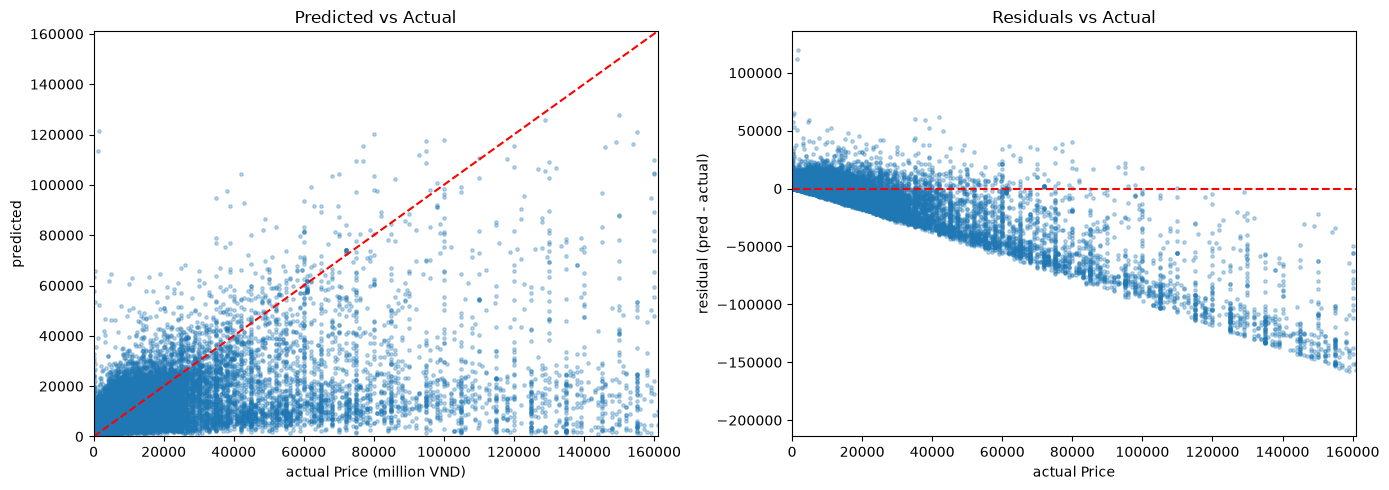

In [33]:
BEST = cmp.index[0]          # model with the lowest validation RMSE
print('selected model:', BEST)

final_pipe = fitted[BEST]
test_scores = regression_scores(y_test, final_pipe.predict(X_test))
for k, v in test_scores.items(): print(f'  {k:7s}: {v:,.3f}')

# predicted vs actual (VND scale)
yp = np.expm1(final_pipe.predict(X_test)); yt = y_test_vnd
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(yt, yp, s=6, alpha=0.3); lim = [0, np.percentile(yt, 99)]
ax[0].plot(lim, lim, 'r--'); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel('actual Price (million VND)'); ax[0].set_ylabel('predicted'); ax[0].set_title('Predicted vs Actual')
resid = yp - yt
ax[1].scatter(yt, resid, s=6, alpha=0.3); ax[1].axhline(0, color='r', ls='--')
ax[1].set_xlim(lim); ax[1].set_xlabel('actual Price'); ax[1].set_ylabel('residual (pred - actual)')
ax[1].set_title('Residuals vs Actual')
plt.tight_layout(); plt.show()

**Metrics.**

- **MAE** — average absolute miss, million VND.
- **RMSE** — squared-error based (punishes large misses), reported on the VND scale.
- **R²** — variance explained vs the mean (verified run: test R² ≈ 0.19).
- **MAPE** — average percentage error.

No confusion matrix (regression). The residual plot widens at higher prices
(heteroscedasticity).

## 20. Error analysis

In [34]:
err = X_test.copy()
err['actual'] = y_test_vnd
err['pred'] = np.expm1(final_pipe.predict(X_test))
err['abs_err'] = (err['pred'] - err['actual']).abs()
err['pct_err'] = err['abs_err'] / err['actual'] * 100

print('worst 10 absolute errors:')
display(err.sort_values('abs_err', ascending=False).head(10)[
    ['Property Type', 'Province', 'district', 'Area', 'actual', 'pred', 'abs_err', 'pct_err']])

print('\nmean |%err| by property type:')
display(err.groupby('Property Type')['pct_err'].mean().sort_values(ascending=False).round(1))

print('\nmean |%err| by area band:')
err['area_band'] = pd.cut(err['Area'], [0, 50, 100, 200, 500, 10000])
display(err.groupby('area_band')['pct_err'].mean().round(1))

worst 10 absolute errors:


,Property Type,Province,district,Area,actual,pred,abs_err,pct_err
16807,Đất,binh-phuoc,Thị xã Chơn Thành,200.0,199000.0,811.811924,198188.188076,99.592054
195047,Căn hộ chung cư,tp-ho-chi-minh,Quận 8,67.0,198000.0,2344.685515,195655.314485,98.815815
103339,Đất,khanh-hoa,Huyện Diên Khánh,568.0,199000.0,3596.900374,195403.099626,98.192512
14384,Căn hộ chung cư,binh-duong,Thị xã Dĩ An,56.0,199000.0,4408.055986,194591.944014,97.784896
129928,Đất,thua-thien-hue,Thị xã Hương Thủy,85.0,195000.0,1573.727071,193426.272929,99.192960
26229,Đất,da-nang,Huyện Hòa Vang,125.0,195000.0,2001.042933,192998.957067,98.973824
37576,Nhà riêng,dong-nai,Thành phố Biên Hòa,65.0,195000.0,2787.123672,192212.876328,98.570706
14330,Căn hộ chung cư,binh-duong,Thị xã Dĩ An,56.0,195000.0,3710.693159,191289.306841,98.097080
14346,Căn hộ chung cư,binh-duong,Thị xã Dĩ An,51.0,195000.0,4102.952511,190897.047489,97.895922
186080,Đất,tp-ho-chi-minh,Huyện Bình Chánh,150.0,195000.0,4360.722747,190639.277253,97.763732



mean |%err| by property type:


Property Type
Kho, nhà xưởng     1256.7
Căn hộ chung cư     507.1
Khách sạn           384.6
Nhà riêng           355.1
Đất                 282.2
Nhà trọ              61.8
Văn phòng            42.5
Name: pct_err, dtype: float64


mean |%err| by area band:


area_band
(0, 50]         471.4
(50, 100]       263.0
(100, 200]      381.5
(200, 500]      299.3
(500, 10000]    464.1
Name: pct_err, dtype: float64

**What the model struggles with.** Largest errors: (i) very large / very cheap
listings (thin data at the extremes); (ii) sparse types like `Kho, nhà xưởng`;
(iii) districts folded into the `infrequent` bucket. Causes: no street-level location,
no year-built / legal-status, skewed target. Fixes: target-encode `district`, add
attributes, per-type models.

## 21. Model selection

**Deployed model: Random Forest** — lowest test RMSE and highest R² of the five.

| Criterion | Random Forest |
|---|---|
| Predictive performance | lowest test RMSE, R² ≈ 0.19, MAE ≈ 10,600 million VND |
| Interpretability | feature importances available |
| Computational cost | ~15 s to train (50k sample), a few ms per prediction |
| Robustness | bagging absorbs the price skew and residual outliers |
| Deployment | ~45 MB pickled, CPU-only |

Linear Regression / Ridge are kept as a smaller, fully-interpretable fallback.

## 22. Model persistence

In [36]:
import joblib, os, json

os.makedirs('../model', exist_ok=True)

# refit the chosen pipeline on train + val so deployment uses all non-test data
deploy_pipe = Pipeline([('prep', preprocessor), ('reg', models[BEST])])
# refit on the training sample + validation set (consistent with section 17)
X_fit = pd.concat([X_tr_s, X_val]); y_fit = np.concatenate([y_tr_s, y_val])
deploy_pipe.fit(X_fit, y_fit)

joblib.dump(deploy_pipe, '../model/model_pipeline.joblib', compress=3)
joblib.dump(FEATURES,    '../model/feature_names.joblib')

schema = {
    'target': 'Price (million VND); model trained on log1p(Price), invert with expm1',
    'task': 'regression',
    'chosen_model': BEST,
    'random_seed': RANDOM_SEED,
    'sklearn_version': sklearn.__version__,
    'price_unit': 'million VND',
    'numeric_features': NUM_FEATURES,
    'categorical_features': CAT_FEATURES,
    'model_features_order': FEATURES,
    'engineered': ['district (parsed from Location: Quận/Huyện/Thị xã/TP token, else ward, else Unknown)',
                   'Bedrooms_missing', 'Bathrooms_missing', 'Floors_missing',
                   '99th-pct cap on Area/Width/Length/Alley Width'],
    'dropped_columns': ['Title (leaks Price)', 'Description', 'Listing ID', 'VIP Account',
                        'Avatar', 'Agent Name', 'Property Type Slug', 'Last Updated',
                        'Scraped At', 'Last Updated Date', 'Latitude', 'Longitude', 'Location'],
}
with open('../model/input_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)

print('saved ../model/model_pipeline.joblib   (preprocessing + regressor in one object)')
print('saved ../model/feature_names.joblib    (expected raw input columns, ordered)')
print('saved ../model/input_schema.json       (input contract for ../api/)')

saved ../model/model_pipeline.joblib   (preprocessing + regressor in one object)
saved ../model/feature_names.joblib    (expected raw input columns, ordered)
saved ../model/input_schema.json       (input contract for ../api/)


**Files produced.** `model/model_pipeline.joblib` (fitted preprocessing + regressor),
`model/feature_names.joblib` (ordered raw columns), `model/input_schema.json` (the
input contract). The API loads exactly these and re-fits nothing.

## 23. Inference test

In [37]:
loaded_pipe     = joblib.load('../model/model_pipeline.joblib')
loaded_features = joblib.load('../model/feature_names.joblib')

raw_listing = {          # exactly what the API / mobile client sends (raw, unprocessed)
    'Area': 78.7, 'Width': 4.0, 'Length': np.nan,
    'Bedrooms': 3, 'Bathrooms': 2, 'Floors': 2, 'Alley Width': np.nan,
    'Agent Listing Count': 2,
    'Property Type': 'Nhà riêng', 'Position': 'Đường chính', 'Direction': 'Nam',
    'Road Type': 'Đường nhựa', 'Province': 'an-giang', 'Agent Role': 'Chính chủ',
    'district': 'Rạch Giá',
}
# the engineered missing-flags the client can't know — derive them the same way the notebook did
for c in ['Bedrooms', 'Bathrooms', 'Floors']:
    raw_listing[c + '_missing'] = int(pd.isna(raw_listing.get(c)))

row = pd.DataFrame([raw_listing])[loaded_features]     # right columns, right order
pred_log = float(loaded_pipe.predict(row)[0])
pred_price = float(np.expm1(pred_log))                 # back to million VND

result = {
    'predicted_price': round(pred_price, 2),
    'price_per_m2': round(pred_price * 1000 / raw_listing['Area'], 2),
    'currency': 'million VND',
    'model': BEST,
}
print(result)

{'predicted_price': 2540.82, 'price_per_m2': 32284.83, 'currency': 'million VND', 'model': 'RandomForest'}


**Contract confirmed.** The reloaded pipeline turns a raw dict into
`{ "predicted_price": …, "price_per_m2": …, "model": … }` via
`validate → saved preprocessing → regressor → expm1`. No preprocessing is re-fitted.
`../api/`'s `POST /predict` wraps this same call.